In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. 데이터 로드 및 베이스 분리
df_train = pd.read_csv("datasets/titanic/train.csv")
X = df_train.drop(columns=['Survived'])
y = df_train['Survived']

# 학습용/평가용으로 데이터 쪼개기 (y_test 생성)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 전처리 파이프라인 구성
# 수치형 변수와 범주형 변수 자동 분류
numeric_features = X_train.select_dtypes(exclude=['object']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# 각각의 전처리 전략 설정 (결측치 채우기 + 스케일링/인코딩)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# 전처리 합치기
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# [핵심] 3. 모델을 포함한 최종 'pipeline' 정의 및 학습
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# 훈련 데이터로 모델 학습시키기 (이 줄이 실행되어야 pipeline 변수가 메모리에 생성됩니다!)
pipeline.fit(X_train, y_train)

# 4. 모델 예측
y_pred = pipeline.predict(X_test)
y_pred_probability = pipeline.predict_proba(X_test)[:, 1]

# 5. 분류 모델 평가
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')
print(f'ROC AUC Score: {roc_auc_score(y_test, y_pred_probability):.4f}')

Accuracy: 0.8212
Precision: 0.8088
Recall: 0.7432
F1 Score: 0.7746
ROC AUC Score: 0.8961


C:\Users\kz4ne\AppData\Local\Temp\ipykernel_29188\3218243546.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object']).columns
C:\DEV\dp_312\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\DEV\dp_312\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 2, 3] during trans

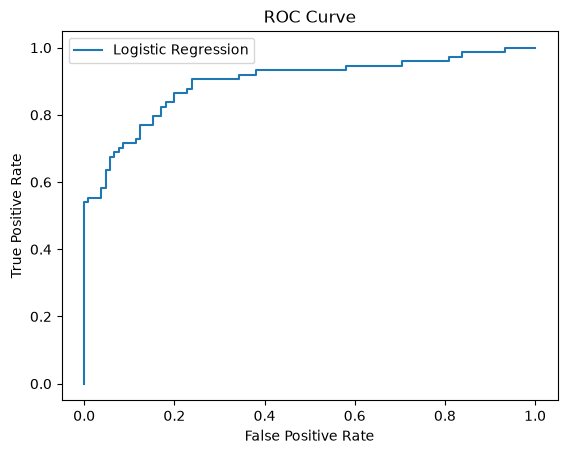

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probability)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix를 출력합니다.
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[92 13]
 [19 55]]


In [13]:
(92+55) / (92+13+19+55)

0.8212290502793296